# RLVR Results

Run all cells to generate paper figures and full results.

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

# Configure matplotlib
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# ============================================
# Configuration
# ============================================
save_dir = './figures'
os.makedirs(save_dir, exist_ok=True)

# wandb project
WANDB_PROJECT = 'verl_grpo_math'
EVAL_METRIC = 'val-aux/DigitalLearningGmbH/MATH-lighteval/reward/mean@1'

# Methods
ALL_METHODS = ['FullTraining', 'LayerWiseSubset', 'GlobalSubset']

LEGEND_NAMES = {
    'FullTraining': 'Full-Training',
    'LayerWiseSubset': 'Layer-Wise Subset',
    'GlobalSubset': 'Global Subset',
}

METHOD_COLORS = {
    'FullTraining': 'black',
    'LayerWiseSubset': 'red',
    'GlobalSubset': 'green',
}

# Run name patterns: method -> regex to match wandb run names
METHOD_PATTERNS = {
    'FullTraining': re.compile(r'^Qwen3-1\.7B_s\d+$'),
    'LayerWiseSubset': re.compile(r'^Qwen3-1\.7B_LayerWiseSubset_s\d+'),
    'GlobalSubset': re.compile(r'^Qwen3-1\.7B_GlobalSubset_s\d+'),
}

print(f"W&B project: {WANDB_PROJECT}")
print(f"Eval metric: {EVAL_METRIC}")
print(f"Methods: {', '.join(ALL_METHODS)}")

W&B project: verl_grpo_math
Eval metric: val-aux/DigitalLearningGmbH/MATH-lighteval/reward/mean@1
Methods: Full-Training, Layer-Wise Subset, Global Subset


## Helper Functions & Load All Data

In [3]:
# ============================================
# Helper functions & Load data from W&B API
# ============================================
import wandb

api = wandb.Api()

def load_run_metric(run, metric_key):
    """Load a single metric's history from a wandb run."""
    history = list(run.scan_history(keys=[metric_key, '_step'], page_size=10000))
    rows = [(h['_step'], h[metric_key]) for h in history if h.get(metric_key) is not None]
    if not rows:
        return None, None
    rows.sort(key=lambda x: x[0])
    steps = np.array([r[0] for r in rows])
    values = np.array([r[1] for r in rows])
    return steps, values

# ============================================
# Load ALL data upfront
# ============================================
# all_data[method_name] = {'steps', 'mean', 'se', 'n_seeds', 'seeds'}

# Fetch all runs from the project
all_runs = list(api.runs(WANDB_PROJECT, per_page=100))

# Group runs by method
method_runs = defaultdict(list)
for run in all_runs:
    for method, pattern in METHOD_PATTERNS.items():
        if pattern.match(run.name):
            method_runs[method].append(run)
            break

all_data = {}

for method in ALL_METHODS:
    runs = method_runs.get(method, [])

    print(f"\n{'='*60}")
    print(f"Loading: {method}")
    print(f"{'='*60}")

    if not runs:
        print(f"  - {method}: Not found")
        continue

    # Load per-seed data
    seed_data = []
    for run in runs:
        steps, values = load_run_metric(run, EVAL_METRIC)
        if steps is not None and len(steps) > 0:
            seed_data.append({'steps': steps, 'values': values, 'name': run.name})
            print(f"  + {run.name}: {len(steps)} points, final={values[-1]:.4f}")
        else:
            print(f"  - {run.name}: no data")

    if not seed_data:
        print(f"  - {method}: No valid runs")
        continue

    # Align to common steps (intersection)
    common_steps = seed_data[0]['steps']
    for sd in seed_data[1:]:
        common_steps = np.intersect1d(common_steps, sd['steps'])

    # Stack values at common steps
    aligned = []
    for sd in seed_data:
        mask = np.isin(sd['steps'], common_steps)
        aligned.append(sd['values'][mask])
    stacked = np.stack(aligned)  # (n_seeds, n_steps)

    n_seeds = len(seed_data)
    se = np.sqrt(n_seeds)  # standard error denominator
    all_data[method] = {
        'steps': common_steps,
        'mean': np.mean(stacked, axis=0),
        'se': np.std(stacked, axis=0) / se,
        'n_seeds': n_seeds,
        'seeds': [sd['name'] for sd in seed_data],
    }
    print(f"  Loaded {n_seeds} seeds, {len(common_steps)} common steps")

print(f"\n{'='*60}")
print(f"All data loaded: {len(all_data)}/{len(ALL_METHODS)} methods")
print(f"{'='*60}")


Loading: Full-Training
  + Qwen3-1.7B_s2: 58 points, final=0.6409
  + Qwen3-1.7B_s42: 59 points, final=0.6323
  + Qwen3-1.7B_s62: 58 points, final=0.6393
  + Qwen3-1.7B_s82: 58 points, final=0.6391
  + Qwen3-1.7B_s22: 58 points, final=0.6479
  Loaded 5 seeds, 58 common steps

Loading: LayerWiseSubset
  + Qwen3-1.7B_LayerWiseSubset_s42_reward: 32 points, final=0.6375
  + Qwen3-1.7B_LayerWiseSubset_s82_reward: 58 points, final=0.6351
  + Qwen3-1.7B_LayerWiseSubset_s22_reward: 58 points, final=0.6478
  + Qwen3-1.7B_LayerWiseSubset_s2_reward: 58 points, final=0.6404
  + Qwen3-1.7B_LayerWiseSubset_s62_reward: 58 points, final=0.6485
  Loaded 5 seeds, 32 common steps

Loading: GlobalSubset
  + Qwen3-1.7B_GlobalSubset_s2_reward: 58 points, final=0.6378
  + Qwen3-1.7B_GlobalSubset_s22_reward: 58 points, final=0.6387
  + Qwen3-1.7B_GlobalSubset_s82_reward: 37 points, final=0.6329
  + Qwen3-1.7B_GlobalSubset_s62_reward: 58 points, final=0.6467
  + Qwen3-1.7B_GlobalSubset_s42_reward: 58 points, 

## Paper Figures: Train Accuracy vs Round

One plot comparing all methods. Shaded regions show mean +/- SE across seeds.


  RLVR: Train Accuracy vs Round
    + Full-Training: 5 seeds, final=0.6303
    + LayerWiseSubset: 5 seeds, final=0.6362
    + GlobalSubset: 5 seeds, final=0.6296
    -> Saved: ./figures/eval_accuracy.pdf


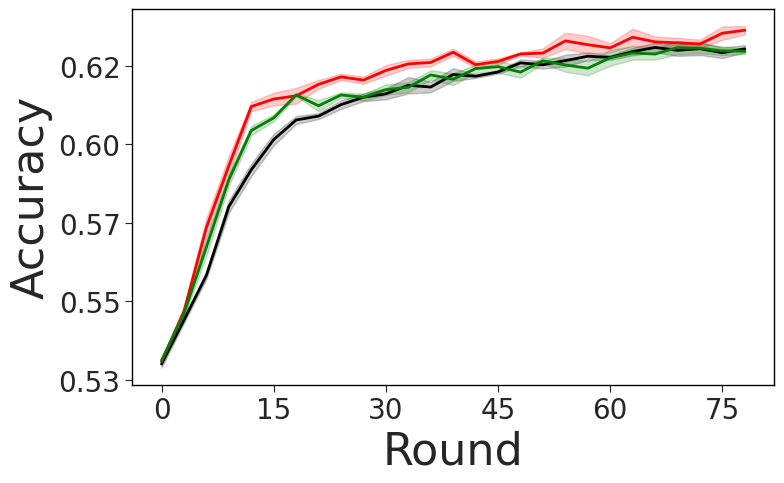


Saved legend: ./figures/legend.pdf


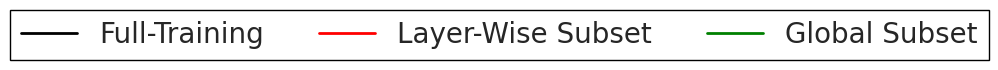

In [4]:
# Paper figure: Train Accuracy vs Round
max_step = 80  # Set to None for all steps

print(f"\n{'='*60}")
print(f"  RLVR: Train Accuracy vs Round")
print(f"{'='*60}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

has_data = False
for method in ALL_METHODS:
    if method not in all_data:
        print(f"    - {method}: no data")
        continue
    data = all_data[method]
    steps = data['steps']
    mean = data['mean']
    se = data['se']

    if max_step is not None:
        mask = steps <= max_step
        steps, mean, se = steps[mask], mean[mask], se[mask]

    color = METHOD_COLORS[method]
    display = LEGEND_NAMES[method]
    ax.plot(steps, mean, linewidth=2, color=color, label=display)
    if data['n_seeds'] > 1:
        ax.fill_between(steps, mean - se, mean + se, color=color, alpha=0.2)
    has_data = True
    print(f"    + {method}: {data['n_seeds']} seeds, final={mean[-1]:.4f}")

ax.set_xlabel('Round', fontsize=32)
ax.set_ylabel('Accuracy', fontsize=32)
ax.grid(True, alpha=0.3, linewidth=0.5)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_color('black')
ax.tick_params(axis='both', which='major', labelsize=20, direction='out', length=5)
ax.xaxis.set_major_locator(plt.MaxNLocator(6))
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))

if not has_data:
    ax.text(0.5, 0.5, 'No data', transform=ax.transAxes, ha='center', fontsize=24, color='gray')

plt.tight_layout()
filepath = os.path.join(save_dir, 'eval_accuracy.pdf')
fig.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"    -> Saved: {filepath}")
plt.show()

# Save a standalone legend figure
legend_labels = [LEGEND_NAMES[m] for m in ALL_METHODS]
legend_colors = [METHOD_COLORS[m] for m in ALL_METHODS]

fig_leg, ax_leg = plt.subplots(figsize=(6, 0.5))
ax_leg.set_axis_off()
handles = [plt.Line2D([0], [0], color=c, linewidth=2) for c in legend_colors]
legend = fig_leg.legend(handles, legend_labels, loc='center', ncol=len(legend_labels),
                        fontsize=20, frameon=True, edgecolor='black', fancybox=False, framealpha=1.0)
legend.get_frame().set_facecolor('white')
fig_leg.patch.set_facecolor('white')
filepath = os.path.join(save_dir, 'legend.pdf')
fig_leg.savefig(filepath, format='pdf', bbox_inches='tight', facecolor='white')
print(f"\nSaved legend: {filepath}")
plt.show()